emitted TOTAL peak rate  5.83e+11 /s
emitted viewport peak rate 4.667e+09 /s
emitted TOTAL bkg rate   4.98e+09 /s (bg photons into 4pi+dark)
emitted viewport+dark bkg rate   3.987e+07 /s (bg photons through 2.75 viewport+ dark)


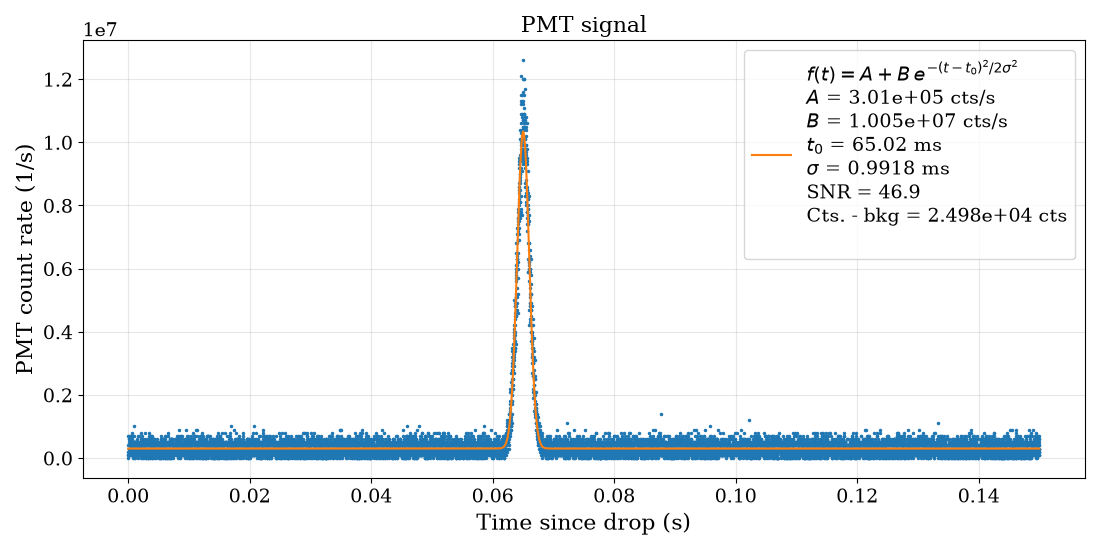

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

%matplotlib widget
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)

rng = np.random.default_rng(0)

#calculate rates emmited by atoms

# --- MEASURED from fit (at the detector, post QE and ray optics) ---
A_rate     = 3e5     # background: scatter + dark, 1/s
B_rate     = 1e7      # peak amplitude above background, 1/s
t0         = 65e-3    # s
sigma      = 1.0e-3   # s

#detector parameters
QE         = 0.1
etta       = 0.0006    # ray optics efficiency
darkRate   = 1e3
saturation = 3.5        # measured rate is low by this factor at the peak

# --- photons at the atoms, implied by the detected rates ---
B_emitted  = B_rate * saturation / (QE * etta)
A_emitted  = (A_rate - darkRate) / (QE * etta)


countRate  = 100e3    # Hz
dt         = 1/countRate

B_sim  = B_emitted / saturation * (QE * etta)
A_sim  = A_emitted * QE * etta + darkRate

def simulated_measured_tof_rate(t):
    return A_sim + B_sim * np.exp(-(t - t0)**2 / (2 * sigma**2))

def pos_gaussian(t, offset, amp, t0, sigma):
    return offset + amp * np.exp(-(t - t0)**2 / (2 * sigma**2))

t    = np.arange(0, .15, dt)
lam  = simulated_measured_tof_rate(t) * dt
cts  = rng.poisson(lam)
rate = cts / dt

p0 = [np.median(rate), rate.max() - np.median(rate), t[np.argmax(rate)], 1e-3]
popt, pcov = curve_fit(pos_gaussian, t, rate, p0=p0)
perr = np.sqrt(np.diag(pcov))
offset, amp, t0_fit, sigma_fit = popt
sigma_fit = abs(sigma_fit)

residuals = rate - pos_gaussian(t, *popt)
resid_std = np.std(residuals, ddof=len(popt))
snr = amp / resid_std
integrated_counts = amp * sigma_fit * np.sqrt(2 * np.pi)

t_fit = np.linspace(t.min(), t.max(), 1000)
fit_label = (
    r'$f(t) = A + B\,e^{-(t-t_0)^2 / 2\sigma^2}$' + '\n'
    f"$A$ = {offset:.4g} cts/s\n"
    f"$B$ = {amp:.4g} cts/s\n"
    f"$t_0$ = {t0_fit*1000:.4g} ms\n"
    f"$\\sigma$ = {sigma_fit*1000:.4g} ms\n"
    f"SNR = {snr:.3g}\n"
    f"Cts. - bkg = {integrated_counts:.4g} cts\n"
)

plt.close('all')
plt.figure(figsize=(11, 5.5))
plt.plot(t, rate, '.', ms=3)
plt.plot(t_fit, pos_gaussian(t_fit, *popt), '-', label=fit_label)
plt.title("PMT signal")
plt.xlabel('Time since drop (s)')
plt.ylabel('PMT count rate (1/s)')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()

print('emitted TOTAL peak rate  %.3g /s'      % B_emitted)
print(f'emitted viewport peak rate {B_emitted*0.008:.3e} /s')
print('emitted TOTAL bkg rate   %.3g /s (bg photons into 4pi+dark)'      % A_emitted)
print(f'emitted viewport+dark bkg rate   {A_emitted*0.008:.3e} /s (bg photons through 2.75 viewport+ dark)')

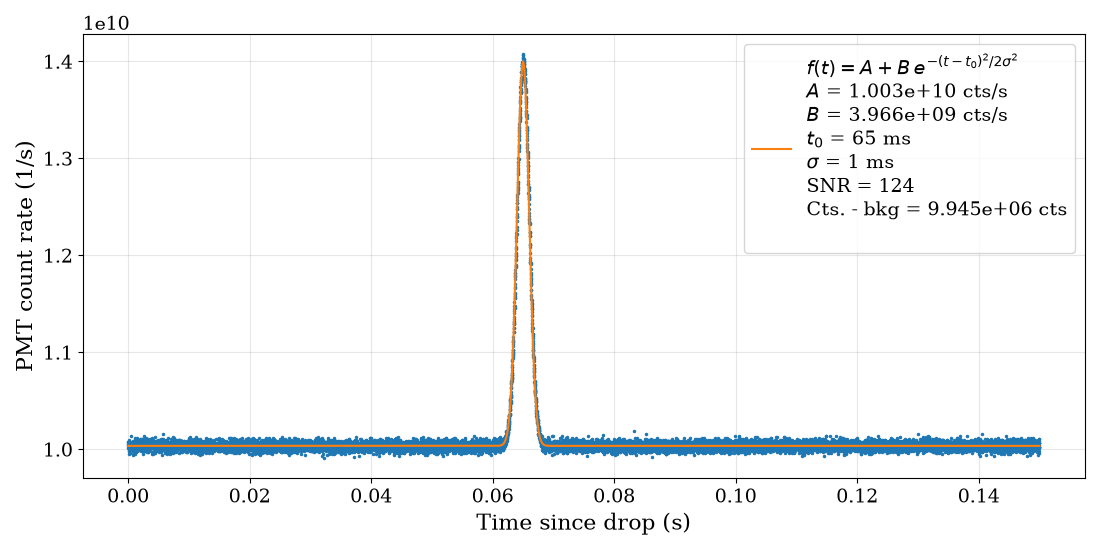

In [28]:
#new detector parameters
QE         = 0.85
etta       = 0.008    # ray optics efficiency
darkRate   = (10e9)
saturation = 1        # measured rate is low by this factor at the peak

countRate  = 100e3    # Hz
dt         = 1/countRate

B_sim  = B_emitted / saturation * (QE * etta)
A_sim  = A_emitted  * QE * etta + darkRate


def simulated_measured_tof_rate(t):
    return A_sim + B_sim * np.exp(-(t - t0)**2 / (2 * sigma**2))

#for curve fit, basically the same, but taken from lyse to have the same fit
def pos_gaussian(t, offset, amp, t0, sigma):
    return offset + amp * np.exp(-(t - t0)**2 / (2 * sigma**2))

t    = np.arange(0, .15, dt)
lam  = simulated_measured_tof_rate(t) * dt          # expected counts per bin
cts  = rng.poisson(lam)
rate = cts / dt

plt.close('all')

p0 = [np.median(rate), rate.max() - np.median(rate), t[np.argmax(rate)], 1e-3]
popt, pcov = curve_fit(pos_gaussian, t, rate, p0=p0)
perr = np.sqrt(np.diag(pcov))
offset, amp, t0_fit, sigma_fit = popt
sigma_fit = abs(sigma_fit)

residuals = rate - pos_gaussian(t, *popt)
resid_std = np.std(residuals, ddof=len(popt))
snr = amp / resid_std
integrated_counts = amp * sigma_fit * np.sqrt(2 * np.pi)

t_fit = np.linspace(t.min(), t.max(), 1000)
fit_label = (
    r'$f(t) = A + B\,e^{-(t-t_0)^2 / 2\sigma^2}$' + '\n'
    f"$A$ = {offset:.4g} cts/s\n"
    f"$B$ = {amp:.4g} cts/s\n"
    f"$t_0$ = {t0_fit*1000:.4g} ms\n"
    f"$\\sigma$ = {sigma_fit*1000:.4g} ms\n"
    f"SNR = {snr:.3g}\n"
    f"Cts. - bkg = {integrated_counts:.4g} cts\n"
)

plt.close('all')
plt.figure(figsize=(11, 5.5))
plt.plot(t, rate, '.', ms=3)
plt.plot(t_fit, pos_gaussian(t_fit, *popt), '-', label=fit_label)
plt.xlabel('Time since drop (s)')
plt.ylabel('PMT count rate (1/s)')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()

In [ ]:
# now we have calculated the total emitted background and peak signal photons after correcting for PMT QE, saturation, optics, dark rate (small)